# Music Genre Classification from Mel-Spectrograms

**Goal.** Classify 30-second music clips into 16 genres using the FMA (Free Music
Archive) dataset — 25,000 Creative-Commons tracks with an official train/validation/test
split.

**Core idea.** We convert the audio problem into an image problem: each clip becomes a
mel-spectrogram (a picture of sound — time × frequency, brightness = energy), where genre
cues like rhythm, timbre, and instrumentation appear as visual texture. This lets us
fine-tune powerful pretrained image models instead of training an audio model from
scratch.

**Evaluation philosophy.** We build a *ladder* of five models — random guessing,
majority-class, logistic regression on hand-crafted features, a CNN trained from scratch,
and a pretrained ConvNeXt — all scored on the same held-out test set, so every increment
of model complexity has to justify itself. Because the genre distribution is heavily
imbalanced, we report macro-F1 alongside accuracy throughout.

**Product.** The final model is exported and deployed as a public web app (Streamlit on
Hugging Face Spaces) with Grad-CAM explanations and similar-track search.

*To run: attach the "FMA - Free Music Archive - Small & Medium" dataset, enable a GPU
(T4), and run top to bottom (see the appendix for caching notes).*

## 0. Environment and data discovery

We verify a GPU is available (training a CNN on 25k images is impractical on CPU) and
locate the dataset files. Rather than hard-coding paths, we search `/kaggle/input`
recursively and build a `track_id → mp3` lookup table — this makes the notebook robust to
how Kaggle happens to mount the dataset. Filenames are filtered to numeric IDs only,
because attached notebook outputs can contain other mp3 files (e.g., demo clips) that are
not FMA tracks.

In [1]:
import os, glob, numpy as np, torch
print("CUDA:", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "(enable GPU!)")

TRACKS_CSV = glob.glob('/kaggle/input/**/tracks.csv', recursive=True)[0]
all_mp3 = glob.glob('/kaggle/input/**/*.mp3', recursive=True)
id_to_path = {int(s): p for p in all_mp3
              if (s := os.path.splitext(os.path.basename(p))[0]).isdigit()}
print("tracks.csv:", TRACKS_CSV)
print("mp3 files found:", len(id_to_path))

WORK = '/kaggle/working'
def audio_path(track_id):
    return id_to_path[track_id]




CUDA: True Tesla T4
tracks.csv: /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata/tracks.csv
mp3 files found: 25000


## 1. Libraries

Two key dependencies: **librosa**, the standard Python library for audio analysis (used to
compute mel-spectrograms), and **fastai**, a high-level deep-learning library on top of
PyTorch that provides well-tuned defaults for transfer learning. We print versions for
reproducibility.

In [2]:
import fastai, librosa
print("fastai", fastai.__version__, "| librosa", librosa.__version__)

fastai 2.8.7 | librosa 0.11.0


## 2. Labels and the official split

We parse FMA's metadata (`tracks.csv`), keep every track that has a top-level genre
label, and — importantly — keep the dataset's **official train/validation/test split**
rather than making our own random split. The official split is artist-disjoint, which
prevents a subtle form of leakage (the model recognizing an *artist's* sound in the test
set rather than the *genre*), and it makes our numbers comparable to published FMA
results.

The printed class distribution motivates two decisions made later: Rock and Electronic
alone are over half the data while Easy Listening has 21 clips, so we will need a
class-aware loss (Section 5) and an imbalance-honest metric (macro-F1).

In [3]:
import pandas as pd
SUBSET = 'medium'                                  # 'medium' (16 genres) or 'small' (8, balanced)
sel = ['small', 'medium'] if SUBSET == 'medium' else ['small']

tracks = pd.read_csv(TRACKS_CSV, index_col=0, header=[0, 1])
subset = tracks[('set', 'subset')]
sub = tracks[subset.isin(sel)]
df = pd.DataFrame({
    'track_id': sub.index,
    'genre':    sub[('track', 'genre_top')].values,
    'split':    sub[('set', 'split')].values,
}).dropna(subset=['genre'])
df = df[df['track_id'].isin(id_to_path)]
print(df.shape, "| genres:", df['genre'].nunique())
print(df['genre'].value_counts())

(25000, 3) | genres: 16
genre
Rock                   7103
Electronic             6314
Experimental           2251
Hip-Hop                2201
Folk                   1519
Instrumental           1350
Pop                    1186
International          1018
Classical               619
Old-Time / Historic     510
Jazz                    384
Country                 178
Soul-RnB                154
Spoken                  118
Blues                    74
Easy Listening           21
Name: count, dtype: int64


## 3. Preprocessing: audio → mel-spectrogram images

Each clip is loaded as 30 s of mono audio at 22,050 Hz and converted to a **128-band
log-mel spectrogram** (FFT window 2048, hop 512). Three choices matter here:

- **Mel scale** spaces frequency bands the way human hearing does, giving more resolution
  where musical information lives.
- **Log (dB) scale**: raw spectrogram energy is dominated by a few loud components; the
  log compresses that range so quiet structure (which carries genre information) becomes
  visible to the model.
- **Per-clip min-max normalization to 8-bit grayscale** removes overall loudness
  differences between recordings, so the model learns spectral *patterns* rather than
  mastering volume.

Images are saved to disk under `spectrograms/<split>/<genre>/<id>.png` — the folder
structure doubles as the label. This step is the slow one (~30–60 min for 25k clips), so
results are cached and reused across sessions.

In [4]:
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

SPEC_DIR = Path(WORK) / 'spectrograms'
SR, N_MELS, N_FFT, HOP = 22050, 128, 2048, 512

def make_spectrogram(track_id, out_path):
    y, sr = librosa.load(audio_path(track_id), sr=SR, mono=True, duration=30)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP)
    S_db = librosa.power_to_db(S, ref=np.max)
    S_norm = ((S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-9) * 255).astype(np.uint8)
    Image.fromarray(np.flipud(S_norm)).save(out_path)

skipped = 0
for row in tqdm(df.itertuples(index=False), total=len(df)):
    genre = str(row.genre).replace('/', '-')        # filesystem-safe label
    out_dir = SPEC_DIR / row.split / genre
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'{row.track_id}.png'
    if out_path.exists():
        continue
    try:
        make_spectrogram(int(row.track_id), out_path)
    except Exception:
        skipped += 1
print("Done. Skipped (corrupt) clips:", skipped)

  0%|          | 0/25000 [00:00<?, ?it/s]

/tmp/ipykernel_24/3634347508.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path(track_id), sr=SR, mono=True, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
/tmp/ipykernel_24/3634347508.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path(track_id), sr=SR, mono=True, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed i

Done. Skipped (corrupt) clips: 15


## 4. DataLoaders

We load the cached spectrograms with labels taken from the parent folder name, resize
every image to 224×224 with a fixed *squish* (no random cropping — a spectrogram's
position encodes time and frequency, so train and inference must be transformed
identically), and normalize with ImageNet statistics because the pretrained backbone
expects inputs in that range. The train/validation assignment follows the folder split
from Section 3, preserving the official artist-disjoint partition.

In [6]:
import glob
from pathlib import Path

cands = glob.glob('/kaggle/input/**/training', recursive=True)
cands = [c for c in cands if glob.glob(c + '/**/*.png', recursive=True)]
print("candidates:", cands)

SPEC_DIR = Path(cands[0]).parent          # the folder containing training/validation/test
print("SPEC_DIR =", SPEC_DIR)
print("spectrograms found:", len(glob.glob(str(SPEC_DIR/'**'/'*.png'), recursive=True)))

candidates: ['/kaggle/input/notebooks/zhihaomu/fma-music-genre-classification/spectrograms/training']
SPEC_DIR = /kaggle/input/notebooks/zhihaomu/fma-music-genre-classification/spectrograms
spectrograms found: 24985


In [7]:
from fastai.vision.all import *

dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=lambda src: get_image_files(src/'training') + get_image_files(src/'validation'),
    get_y=parent_label,
    splitter=FuncSplitter(lambda o: Path(o).parent.parent.name == 'validation'),
    item_tfms=Resize(224, method=ResizeMethod.Squish),
    batch_tfms=Normalize.from_stats(*imagenet_stats),
).dataloaders(SPEC_DIR, bs=64)

print("Genres (%d):" % len(dls.vocab), list(dls.vocab))
print("train / valid sizes:", len(dls.train_ds), len(dls.valid_ds))

Genres (16): ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time - Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']
train / valid sizes: 19909 2504


## 5. Loss function and metrics

With Rock outnumbering Easy Listening 400:1, an unweighted loss lets the majority genres
dominate training. Our fix is **square-root-dampened inverse-frequency class weights,
capped at 3×**. The dampening and cap are the result of an instructive failure: raw
inverse-frequency weights (up to ~437× for the rarest genre) pushed the model to
over-predict rare genres and collapsed accuracy to 9% — a worse-than-majority-class
model. The capped version gives rare genres a nudge, not a veto. We add **label smoothing
(0.1)**, which prevents overconfident predictions and improves calibration.

For metrics we track accuracy *and* **macro-F1** (the unweighted mean of per-genre F1).
Accuracy answers "how many clips are right"; macro-F1 answers "how well does the model do
per genre, treating all 16 equally" — the honest number under imbalance.

In [8]:
from collections import Counter
train_files = get_image_files(SPEC_DIR/'training')
cnt     = Counter(parent_label(f) for f in train_files)
counts  = tensor([cnt[c] for c in dls.vocab]).float()


w = (counts.mean() / counts).sqrt().clamp(max=3.0)
loss = CrossEntropyLossFlat(weight=w.to(dls.device), label_smoothing=0.1)

metrics = [accuracy, F1Score(average='macro')]
print("per-class training counts:", {c: int(n) for c, n in zip(dls.vocab, counts)})

per-class training counts: {'Blues': 58, 'Classical': 495, 'Country': 142, 'Easy Listening': 13, 'Electronic': 5048, 'Experimental': 1800, 'Folk': 1214, 'Hip-Hop': 1757, 'Instrumental': 1044, 'International': 814, 'Jazz': 306, 'Old-Time - Historic': 408, 'Pop': 945, 'Rock': 5677, 'Soul-RnB': 94, 'Spoken': 94}


## 6a. Main model: fine-tuned ConvNeXt-Tiny (transfer learning)

Our main classifier is **ConvNeXt-Tiny pretrained on ImageNet-22k** (~28M parameters),
fine-tuned on our spectrograms. The transfer-learning hypothesis: a network that already
knows edges, textures, and shapes from 14M natural images should adapt to spectrogram
textures far faster than one starting from random weights (Section 6b tests exactly this).
We chose ConvNeXt over the classic ResNet because it is a more modern architecture with a
stronger pretraining corpus at similar cost.

Training choices, each with a reason:
- **`fine_tune` (2 frozen + 24 unfrozen epochs)** — first trains only the new
  classification head while the pretrained body is frozen, then unfreezes everything at
  discriminative learning rates; this protects pretrained features early on.
- **MixUp augmentation** — blends pairs of training images and labels; a strong
  regularizer we added after observing overfitting (validation loss rising while training
  loss fell).
- **Best-epoch checkpointing (`SaveModelCallback` on macro-F1)** — training past the
  optimum can no longer degrade the exported model.
- **Mixed precision (`to_fp16`)** — ~2× faster on the T4 GPU at no accuracy cost.

In [9]:
learn = vision_learner(dls, 'convnext_tiny.fb_in22k', loss_func=loss, metrics=metrics,
                       cbs=[MixUp(),
                            SaveModelCallback(monitor='f1_score')]).to_fp16()
learn.fine_tune(24, base_lr=1e-3, freeze_epochs=2)

model.safetensors:   0%|          | 0.00/178M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.799925,2.580801,0.517971,0.302800,01:37
1,2.217490,2.313688,0.593850,0.369883,01:21


Better model found at epoch 0 with f1_score value: 0.30279965637222944.
Better model found at epoch 1 with f1_score value: 0.36988281647977284.


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.045597,2.253875,0.614217,0.386839,01:50
1,2.037615,2.231072,0.633786,0.407664,01:45
2,1.978944,2.212470,0.630591,0.408989,01:44
3,1.927201,2.202068,0.638978,0.408592,01:45
4,1.902840,2.192604,0.636581,0.423508,01:45
5,1.846212,2.164646,0.653355,0.425383,01:45
6,1.806963,2.142706,0.658546,0.429149,01:45
7,1.793704,2.149006,0.657748,0.451396,01:45
8,1.768998,2.141259,0.658946,0.438354,01:45
9,1.749984,2.150231,0.646965,0.421923,01:45


Better model found at epoch 0 with f1_score value: 0.38683891170630047.
Better model found at epoch 1 with f1_score value: 0.40766357950745735.
Better model found at epoch 2 with f1_score value: 0.4089887564468011.
Better model found at epoch 4 with f1_score value: 0.4235082919374125.
Better model found at epoch 5 with f1_score value: 0.4253828782284207.
Better model found at epoch 6 with f1_score value: 0.42914938342831566.
Better model found at epoch 7 with f1_score value: 0.4513959766379425.


## 6b. Comparison model: SimpleCNN trained from scratch

To measure what pretraining is actually worth, we train a hand-built five-block CNN
(~1M parameters) from random initialization under a **controlled comparison**: same data,
same loss, same metrics, same checkpointing rule. Only the architecture and
initialization differ. If transfer learning matters on spectrograms, ConvNeXt should
converge faster and/or score higher; if spectrograms are too unlike natural images for
ImageNet features to transfer, the gap should be small. Section 9 shows the outcome.

In [10]:
# 6b. SimpleCNN — run AFTER the ConvNeXt cell (comparison model, same dls + loss)
import torch.nn as nn

def conv_block(ic, oc):
    return nn.Sequential(nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc),
                         nn.ReLU(inplace=True), nn.MaxPool2d(2))

class SimpleCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.body = nn.Sequential(conv_block(3,32), conv_block(32,64), conv_block(64,128),
                                  conv_block(128,256), conv_block(256,256))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(256, len(dls.vocab)))
    def forward(self, x): return self.head(self.body(x))

learn_cnn = Learner(dls, SimpleCNN(len(dls.vocab)), loss_func=loss, metrics=metrics,
                    cbs=[SaveModelCallback(monitor='f1_score', fname='best_cnn')]).to_fp16()
learn_cnn.fit_one_cycle(25, lr_max=2e-3, wd=0.1)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.431692,2.402793,0.543930,0.282898,00:58
1,2.366590,2.399512,0.574281,0.282349,00:58
2,2.288691,2.333730,0.590655,0.316962,00:59
3,2.266484,2.369589,0.554313,0.336156,00:59
4,2.250013,2.728805,0.489217,0.177944,01:00
5,2.202036,2.607416,0.499201,0.268413,00:59
6,2.182081,3.169459,0.343051,0.180380,00:59
7,2.126118,2.726661,0.483626,0.312879,00:59
8,2.110442,2.432650,0.507987,0.368353,00:59
9,2.081806,2.286274,0.615815,0.341366,00:59


Better model found at epoch 0 with f1_score value: 0.2828983463618817.
Better model found at epoch 2 with f1_score value: 0.3169618897633967.
Better model found at epoch 3 with f1_score value: 0.3361561263726423.
Better model found at epoch 8 with f1_score value: 0.3683529612076685.
Better model found at epoch 11 with f1_score value: 0.3827585349710263.
Better model found at epoch 13 with f1_score value: 0.439704285806701.
Better model found at epoch 18 with f1_score value: 0.4415697217426834.
Better model found at epoch 20 with f1_score value: 0.45239752462766747.
Better model found at epoch 21 with f1_score value: 0.46177235895219415.
Better model found at epoch 23 with f1_score value: 0.4686898594388963.
Better model found at epoch 24 with f1_score value: 0.471334158618698.


## 6c. Baselines: how much do deep networks actually buy?

Deep models should not get credit for performance a simple method could achieve. We score
three baselines on the same test split:

- **Random guessing** — the floor (~6% for 16 classes).
- **Majority class** — always predict Rock; exposes how much accuracy imbalance alone
  can fake (~28%) while macro-F1 stays near zero.
- **Logistic regression on mel-band statistics** — a classic non-deep audio baseline
  using 256 hand-crafted features (per-band mean and standard deviation of the
  spectrogram). This measures how far *features + a linear model* go before any
  representation learning.

Together with 6a/6b these form a five-rung ladder in which each added level of model
complexity must justify itself.

In [11]:
# 6c. Baselines
import numpy as np, pandas as pd
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

def feats(png):
    a = np.asarray(Image.open(png), dtype=np.float32) / 255.
    return np.concatenate([a.mean(axis=1), a.std(axis=1)])      # 256 features

def load_split(split):
    files = get_image_files(SPEC_DIR/split)
    X = np.stack([feats(f) for f in tqdm(files, desc=split)])
    return X, np.array([parent_label(f) for f in files])

Xtr, ytr = load_split('training')
Xte, yte = load_split('test')

results = {}
rng = np.random.default_rng(0)
rand = rng.choice(np.unique(ytr), size=len(yte))
results['Random guess'] = ((rand == yte).mean(),
                           f1_score(yte, rand, average='macro'))
maj = pd.Series(ytr).mode()[0]
results[f'Majority class ({maj})'] = ((yte == maj).mean(),
    f1_score(yte, np.full_like(yte, maj), average='macro'))
lr = LogisticRegression(max_iter=2000, n_jobs=-1).fit(Xtr, ytr)
pred = lr.predict(Xte)
results['Logistic regression (mel stats)'] = ((pred == yte).mean(),
    f1_score(yte, pred, average='macro'))
for k, (a, f) in results.items():
    print(f'{k:35s} acc {a:.3f} | macro-F1 {f:.3f}')

training:   0%|          | 0/19909 [00:00<?, ?it/s]

test:   0%|          | 0/2572 [00:00<?, ?it/s]

Random guess                        acc 0.066 | macro-F1 0.048
Majority class (Rock)               acc 0.276 | macro-F1 0.027
Logistic regression (mel stats)     acc 0.564 | macro-F1 0.293


## 7. Per-genre evaluation

Headline accuracy hides failure modes, so we inspect the full classification report and
confusion matrix on the validation set. Two patterns to look for: genres with few
training clips (Blues: 58, Easy Listening: 13) should fail for *data* reasons, while Pop
— which has 945 clips — fails for *label fuzziness* reasons, scattering into Rock and
Electronic. The confusion matrix distinguishes these two failure types, which a single
accuracy number cannot.

                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         8
          Classical       0.78      0.87      0.82        62
            Country       0.23      0.17      0.19        18
     Easy Listening       0.00      0.00      0.00         2
         Electronic       0.70      0.73      0.72       631
       Experimental       0.48      0.39      0.43       225
               Folk       0.59      0.72      0.65       152
            Hip-Hop       0.74      0.70      0.72       220
       Instrumental       0.35      0.43      0.38       131
      International       0.60      0.68      0.64       102
               Jazz       0.19      0.26      0.22        39
Old-Time - Historic       0.85      0.76      0.80        51
                Pop       0.12      0.10      0.11       122
               Rock       0.85      0.81      0.83       711
           Soul-RnB       0.09      0.06      0.07        18
             Spoken    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


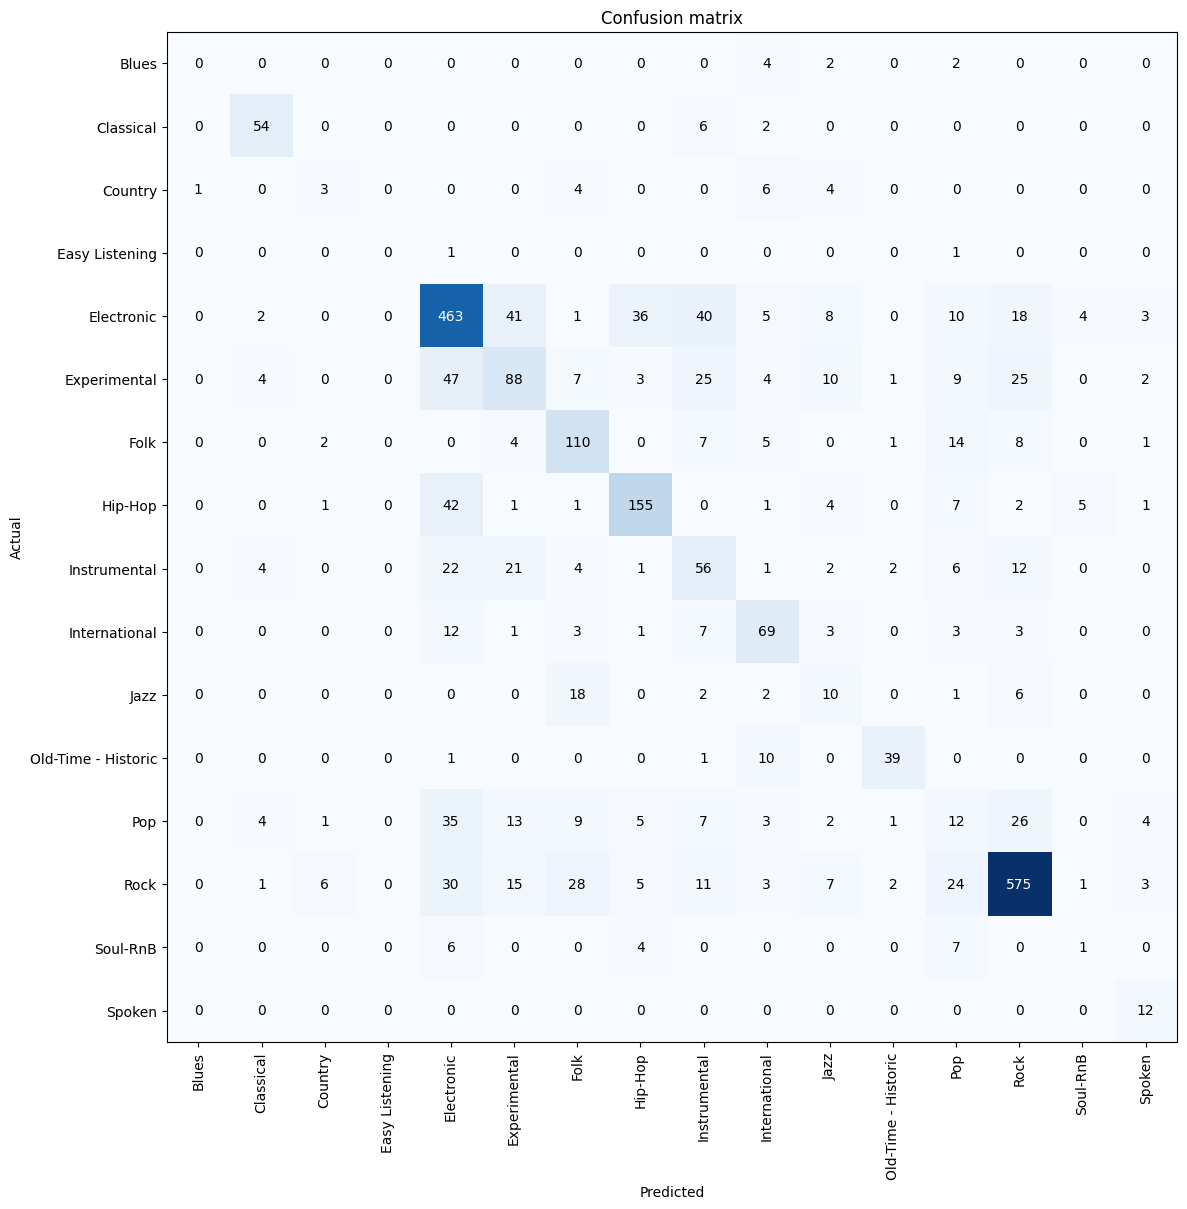

In [12]:
interp = ClassificationInterpretation.from_learner(learn)
print(interp.print_classification_report())
interp.plot_confusion_matrix(figsize=(12, 12))

## 8. Final test score and model archive

The test split is used **once**, here, after all modeling decisions are frozen — this is
what makes it an unbiased estimate of real-world performance (the validation set, used
for checkpoint selection, is no longer neutral). We also archive the trained learner as a
`.pkl` for reproducibility within this environment; the deployment export (Section 10)
uses a more portable format.

In [13]:
from sklearn.metrics import f1_score
test_files = get_image_files(SPEC_DIR/'test')
test_dl = learn.dls.test_dl(test_files, with_labels=True)
preds, targs = learn.get_preds(dl=test_dl)
print(f"Test accuracy: {accuracy(preds, targs).item():.4f}")
print(f"Test macro-F1: {f1_score(targs, preds.argmax(1), average='macro'):.4f}")

learn.export(f'{WORK}/genre_convnext_{SUBSET}.pkl')
print("Saved:", f'{WORK}/genre_convnext_{SUBSET}.pkl')

Test accuracy: 0.6233
Test macro-F1: 0.4232
Saved: /kaggle/working/genre_convnext_medium.pkl


In [14]:
import sys, torch, fastai, fastcore, timm
print(sys.version.split()[0], "| torch", torch.__version__, "| fastai", fastai.__version__,
      "| fastcore", fastcore.__version__, "| timm", timm.__version__)

3.12.13 | torch 2.10.0+cu128 | fastai 2.8.7 | fastcore 1.12.36 | timm 1.0.26


## 9. The model ladder: final comparison

All five models on the identical test split, in one table. Reading it bottom-up shows
what each increment buys: features + linear model over guessing, representation learning
over hand-crafted features, and (with caveats discussed in the report) pretraining over
from-scratch training. The table is saved as `model_comparison.csv`.

In [ ]:
test_files = get_image_files(SPEC_DIR/'test')
for name, l in [('SimpleCNN (from scratch)', learn_cnn),
                ('ConvNeXt-Tiny (pretrained)', learn)]:
    dl = l.dls.test_dl(test_files, with_labels=True)
    preds, targs = l.get_preds(dl=dl)
    results[name] = (accuracy(preds, targs).item(),
                     f1_score(targs, preds.argmax(1), average='macro'))

tbl = pd.DataFrame([(k, round(a, 3), round(f, 3)) for k, (a, f) in results.items()],
                   columns=['model', 'test_accuracy', 'test_macro_F1'])
print(tbl.to_string(index=False))
tbl.to_csv('/kaggle/working/model_comparison.csv', index=False)

                          model  test_accuracy  test_macro_F1
                   Random guess          0.066          0.048
          Majority class (Rock)          0.276          0.027
Logistic regression (mel stats)          0.564          0.293
       SimpleCNN (from scratch)          0.636          0.433
     ConvNeXt-Tiny (pretrained)          0.623          0.423


## 10. Export for deployment

The web app must load this model outside the training environment, and fastai's pickled
export is coupled to exact library versions (we verified this breaks in practice). Our
solution: export **raw weights plus a declarative description of the head**, then rebuild
the network in plain PyTorch + timm and **numerically verify** — inside this notebook,
where the original model exists — that the rebuilt model produces identical outputs
before saving. The deployed app therefore has zero fastai dependency.

The second cell exports the app's supporting artifacts: the confusion matrix and
per-genre F1 table (methodology page), penultimate-layer embeddings of the validation
tracks (similar-track search), and two sample clips per genre (one-click demos).

In [15]:
# ============ PLAIN EXPORT — pure-torch model file ============
ARCH = 'convnext_tiny.fb_in22k'      # the timm arch you trained

import torch, torch.nn as nn, torch.nn.functional as F, timm

model = learn.model.eval().float().cpu()
body_fastai, head_fastai = model[0], model[1]
body_raw = getattr(body_fastai, 'model', body_fastai)   # unwrap TimmBody

# --- describe the head as a plain spec ---
spec = []
for m in head_fastai.children():
    n = type(m).__name__
    if n == 'AdaptiveConcatPool2d':      spec.append(['concat_pool'])
    elif n == 'Flatten':                 spec.append(['flatten'])
    elif isinstance(m, nn.BatchNorm1d):  spec.append(['bn', m.num_features])
    elif isinstance(m, nn.Dropout):      spec.append(['dropout', m.p])
    elif isinstance(m, nn.Linear):       spec.append(['linear', m.in_features,
                                                      m.out_features,
                                                      m.bias is not None])
    elif isinstance(m, nn.ReLU):         spec.append(['relu'])
    else:
        print(head_fastai); raise ValueError(f'unexpected head layer: {n}')

# --- rebuild in plain torch and VERIFY ---
class ConcatPool(nn.Module):
    def forward(self, x):
        return torch.cat([F.adaptive_max_pool2d(x, 1),
                          F.adaptive_avg_pool2d(x, 1)], dim=1)

def build_head(spec):
    L = []
    for s in spec:
        k = s[0]
        if k == 'concat_pool': L.append(ConcatPool())
        elif k == 'flatten':   L.append(nn.Flatten(1))
        elif k == 'bn':        L.append(nn.BatchNorm1d(s[1]))
        elif k == 'dropout':   L.append(nn.Dropout(s[1]))
        elif k == 'linear':    L.append(nn.Linear(s[1], s[2], bias=s[3]))
        elif k == 'relu':      L.append(nn.ReLU(inplace=True))
    return nn.Sequential(*L)

class FeatureBody(nn.Module):
    """fastai's TimmBody calls forward_features(), NOT the full forward()
    — the full forward would also apply timm's own head norm/pool."""
    def __init__(self, m):
        super().__init__(); self.m = m
    def forward(self, x):
        return self.m.forward_features(x)

body2 = timm.create_model(ARCH, pretrained=False, num_classes=0)
body2.load_state_dict(body_raw.state_dict())
head2 = build_head(spec); head2.load_state_dict(head_fastai.state_dict())
plain = nn.Sequential(FeatureBody(body2), head2).eval()

x = torch.randn(2, 3, 224, 224)
with torch.no_grad():
    diff = (plain(x) - model(x)).abs().max().item()
print('max output diff:', diff)
assert diff < 1e-4, 'rebuild mismatch — send Claude the printed head above'

torch.save({'arch': ARCH, 'vocab': list(learn.dls.vocab), 'head_spec': spec,
            'body_sd': body2.state_dict(), 'head_sd': head2.state_dict()},
           '/kaggle/working/genre_model_plain.pt')
print('SAVED genre_model_plain.pt | genres:', list(learn.dls.vocab))
# ===============================================================

max output diff: 0.0
SAVED genre_model_plain.pt | genres: ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time - Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']


In [16]:
# ============ ARTIFACTS EXPORT ============
import os, glob, shutil, random, zipfile
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report
from fastai.vision.all import ClassificationInterpretation, get_image_files

OUT = '/kaggle/working/app_artifacts'; os.makedirs(OUT, exist_ok=True)

# 1. Confusion matrix + per-class F1 (validation set)
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(10, 10))
plt.savefig(f'{OUT}/confusion_matrix.png', bbox_inches='tight'); plt.close('all')

preds, targs = learn.get_preds()
vocab = list(learn.dls.vocab)
rep = classification_report(targs.numpy(), preds.argmax(1).numpy(),
                            target_names=vocab, output_dict=True)
pd.DataFrame([{'genre': g, 'precision': rep[g]['precision'],
               'recall': rep[g]['recall'], 'f1': rep[g]['f1-score'],
               'support': int(rep[g]['support'])} for g in vocab]
             ).round(3).to_csv(f'{OUT}/per_class_f1.csv', index=False)

# 2. Embeddings with the PLAIN model (must match app.py's embed_clip)
#    Names use artist/title from tracks.csv (`tracks` from the labels cell).
import torch
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])[:, None, None]

meta_a, meta_t = tracks[('artist', 'name')], tracks[('track', 'title')]
def track_name(tid, genre):
    a, t = meta_a.get(tid), meta_t.get(tid)
    a = str(a) if pd.notna(a) else 'Unknown artist'
    t = str(t) if pd.notna(t) else f'track {tid}'
    return f'{a} — {t}  ({genre})'
def prep(png):
    img = Image.open(png).convert('RGB').resize((224, 224))
    t = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.
    return (t - IMAGENET_MEAN) / IMAGENET_STD

plain_gpu = plain.cuda().eval()
val_pngs = get_image_files(SPEC_DIR/'validation')
embs, names = [], []
with torch.no_grad():
    for i in range(0, len(val_pngs), 64):
        batch = torch.stack([prep(p) for p in val_pngs[i:i+64]]).cuda()
        f = plain_gpu[0](batch)
        v = ConcatPool()(f).flatten(1).cpu().numpy()
        embs.append(v)
        names += [track_name(int(p.stem), p.parent.name)
                  for p in val_pngs[i:i+64]]
embs = np.concatenate(embs).astype(np.float32)
np.savez_compressed(f'{OUT}/embeddings.npz', emb=embs,
                    names=np.array(names, dtype=object))
plain = plain.cpu()

# 3. Sample clips: 2 mp3s per genre, named "Artist - Title.mp3"
#    (uses df + id_to_path from cells 0/2)
import re
def safe(s, n=60):
    return re.sub(r'[^\w\- .,()]', '', str(s))[:n].strip() or 'unknown'

for g in df['genre'].unique():
    ids = df[df['genre'] == g]['track_id'].sample(2, random_state=0)
    d = f"{OUT}/samples/{str(g).replace('/', '-')}"; os.makedirs(d, exist_ok=True)
    for tid in ids:
        tid = int(tid)
        dst = f"{d}/{safe(f'{meta_a.get(tid)} - {meta_t.get(tid)}')}.mp3"
        if os.path.exists(dst):
            dst = dst[:-4] + f' [{tid}].mp3'
        shutil.copy(id_to_path[tid], dst)

# 4. Zip
with zipfile.ZipFile('/kaggle/working/app_artifacts.zip', 'w') as z:
    for root, _, files in os.walk(OUT):
        for f in files:
            fp = os.path.join(root, f)
            z.write(fp, os.path.relpath(fp, OUT))
print('DONE -> download /kaggle/working/app_artifacts.zip')
# ==========================================

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


DONE -> download /kaggle/working/app_artifacts.zip
